# Analyse des données énergétiques européennes

Projet M1 IMDS

Objectifs :
- Stocker les données des pays européens dans MongoDB
- Comparer le mix énergétique de plusieurs pays
- Étudier l'évolution de la consommation énergétique en France
- Analyser les corrélations avec la population et d'autres variables
- Créer des visualisations interactives avec Plotly/Dash

In [11]:
from google.colab import drive
import os
import json

# Monter Google Drive dans un nouveau dossier
drive.mount("/content/gdrive")

# Dossier du projet dans Google Drive
PROJECT_DIR = "/content/gdrive/MyDrive/M1_IMDS_Energy"

# Vérification du contenu
print("Contenu du dossier projet :")
for file in os.listdir(PROJECT_DIR):
    print("-", file)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Contenu du dossier projet :
- owid-energy-data.json
- README.md
- energy_europe_analysis.ipynb
- images


In [12]:
JSON_PATH = os.path.join(PROJECT_DIR, "owid-energy-data.json")

with open(JSON_PATH, "r", encoding="utf-8") as f:
    energy_data = json.load(f)

print("Dataset chargé avec succès")
print("Nombre d'entrées :", len(energy_data))

Dataset chargé avec succès
Nombre d'entrées : 294


In [13]:
IMAGES_DIR = os.path.join(PROJECT_DIR, "images")

print("Dossier images :", IMAGES_DIR)

Dossier images : /content/gdrive/MyDrive/M1_IMDS_Energy/images


In [14]:
type(energy_data)

dict

In [15]:
len(energy_data)

294

In [16]:
list(energy_data.keys())[:20]

['ASEAN (Ember)',
 'Afghanistan',
 'Africa',
 'Africa (EI)',
 'Africa (EIA)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Albania',
 'Algeria',
 'American Samoa',
 'Angola',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Asia',
 'Asia & Oceania (EIA)',
 'Asia (Ember)',
 'Asia Pacific (EI)']

In [17]:
energy_data["France"].keys()

dict_keys(['iso_code', 'data'])

In [18]:
energy_data["France"]["iso_code"]

'FRA'

In [19]:
len(energy_data["France"]["data"])

124

In [20]:
energy_data["France"]["data"][0]

{'year': 1900,
 'population': 40019136,
 'gdp': 186101235712.0,
 'coal_prod_per_capita': 6739.92529296875,
 'coal_production': 269.7259826660156,
 'gas_prod_per_capita': 0.0,
 'gas_production': 0.0,
 'oil_prod_per_capita': 0.0,
 'oil_production': 0.0}

In [21]:
european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czechia", "Denmark", "Estonia", "Finland", "France",
    "Germany", "Greece", "Hungary", "Iceland", "Ireland",
    "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Moldova", "Montenegro", "Netherlands", "North Macedonia",
    "Norway", "Poland", "Portugal", "Romania", "Russia",
    "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden",
    "Switzerland", "Ukraine", "United Kingdom"
]

In [22]:
available_european_countries = [
    country for country in european_countries
    if country in energy_data
]

len(available_european_countries)

40

In [23]:
available_european_countries

['Albania',
 'Austria',
 'Belarus',
 'Belgium',
 'Bosnia and Herzegovina',
 'Bulgaria',
 'Croatia',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'Iceland',
 'Ireland',
 'Italy',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Malta',
 'Moldova',
 'Montenegro',
 'Netherlands',
 'North Macedonia',
 'Norway',
 'Poland',
 'Portugal',
 'Romania',
 'Russia',
 'Serbia',
 'Slovakia',
 'Slovenia',
 'Spain',
 'Sweden',
 'Switzerland',
 'Ukraine',
 'United Kingdom']

In [24]:
missing_countries = [
    country for country in european_countries
    if country not in energy_data
]

missing_countries

['Andorra']

In [25]:
europe_data = []

for country in available_european_countries:
    document = {
        "country": country,
        "iso_code": energy_data[country].get("iso_code"),
        "data": energy_data[country]["data"]
    }

    europe_data.append(document)

In [26]:
len(europe_data)

40

In [27]:
europe_data[0]

{'country': 'Albania',
 'iso_code': 'ALB',
 'data': [{'year': 1900,
   'population': 805974,
   'gdp': 873600000.0,
   'coal_prod_per_capita': 0.0,
   'coal_production': 0.0,
   'gas_prod_per_capita': 0.0,
   'gas_production': 0.0,
   'oil_prod_per_capita': 0.0,
   'oil_production': 0.0},
  {'year': 1901,
   'population': 813539,
   'coal_prod_change_twh': 0.0,
   'coal_prod_per_capita': 0.0,
   'coal_production': 0.0,
   'gas_prod_change_twh': 0.0,
   'gas_prod_per_capita': 0.0,
   'gas_production': 0.0,
   'oil_prod_change_twh': 0.0,
   'oil_prod_per_capita': 0.0,
   'oil_production': 0.0},
  {'year': 1902,
   'population': 821036,
   'coal_prod_change_twh': 0.0,
   'coal_prod_per_capita': 0.0,
   'coal_production': 0.0,
   'gas_prod_change_twh': 0.0,
   'gas_prod_per_capita': 0.0,
   'gas_production': 0.0,
   'oil_prod_change_twh': 0.0,
   'oil_prod_per_capita': 0.0,
   'oil_production': 0.0},
  {'year': 1903,
   'population': 828461,
   'coal_prod_change_twh': 0.0,
   'coal_prod_pe

In [28]:
print(europe_data[0]["country"])
print(europe_data[0]["iso_code"])
print(len(europe_data[0]["data"]))

Albania
ALB
123


In [29]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.8 MB/s eta 0:00:00


In [30]:
from pymongo import MongoClient
from getpass import getpass
from urllib.parse import quote_plus

username = "naimaassoulaimani80_db_user"
password = getpass("Mot de passe MongoDB : ")

password_encoded = quote_plus(password)

uri = (
    f"mongodb+srv://{username}:{password_encoded}"
    "@energycluster.ei4fvmy.mongodb.net/"
    "?appName=EnergyCluster"
)

client = MongoClient(uri)

Mot de passe MongoDB : ··········


In [31]:
client.admin.command("ping")

{'ok': 1}

In [32]:
db = client["energy_db"]
collection = db["europe_energy"]

In [33]:
for document in europe_data:
    collection.update_one(
        {"iso_code": document["iso_code"]},
        {"$set": document},
        upsert=True
    )

In [34]:
collection.count_documents({})

40

In [35]:
collection.find_one(
    {"country": "France"},
    {"_id": 0, "country": 1, "iso_code": 1}
)

{'iso_code': 'FRA', 'country': 'France'}

In [36]:
import pandas as pd

france_doc = collection.find_one({"country": "France"})
germany_doc = collection.find_one({"country": "Germany"})

In [37]:
france_df = pd.DataFrame(france_doc["data"])
germany_df = pd.DataFrame(germany_doc["data"])

In [38]:
france_df.shape, germany_df.shape

((124, 127), (124, 127))

In [39]:
france_df.head()

,year,population,gdp,coal_prod_per_capita,coal_production,gas_prod_per_capita,gas_production,oil_prod_per_capita,oil_production,coal_prod_change_pct,...,wind_share_energy,solar_cons_change_twh,wind_cons_change_pct,wind_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_share_energy,biofuel_cons_change_pct,biofuel_cons_change_twh,solar_cons_change_pct
0,1900,40019136,1.861012e+11,6739.925293,269.725983,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1901,40067484,1.830832e+11,6511.827148,260.912537,0.0,0.0,0.0,0.0,-3.267556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1902,40116538,1.800736e+11,6036.102539,242.147537,0.0,0.0,0.0,0.0,-7.192063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1903,40166299,1.840672e+11,7018.971191,281.926086,0.0,0.0,0.0,0.0,16.427399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1904,40216118,1.854181e+11,6862.744141,275.992920,0.0,0.0,0.0,0.0,-2.104509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
[col for col in france_df.columns if "share_energy" in col]

['coal_share_energy',
 'fossil_share_energy',
 'gas_share_energy',
 'hydro_share_energy',
 'low_carbon_share_energy',
 'nuclear_share_energy',
 'oil_share_energy',
 'other_renewables_share_energy',
 'renewables_share_energy',
 'electricity_share_energy',
 'solar_share_energy',
 'wind_share_energy',
 'biofuel_share_energy']

In [41]:
[col for col in france_df.columns if "share_elec" in col]

['coal_share_elec',
 'fossil_share_elec',
 'gas_share_elec',
 'hydro_share_elec',
 'nuclear_share_elec',
 'oil_share_elec',
 'other_renewables_share_elec',
 'biofuel_share_elec',
 'low_carbon_share_elec',
 'other_renewables_share_elec_exc_biofuel',
 'renewables_share_elec',
 'solar_share_elec',
 'wind_share_elec']

### Comparaison du mix électrique entre la France et l'Allemagne

Dans cette partie, on compare la part des principales sources d'électricité
(charbon, gaz, pétrole, nucléaire, hydraulique, solaire et éolien)
dans les deux pays.

In [42]:
# Variables utilisées pour comparer le mix électrique
# On garde les principales sources de production d'électricité
energy_sources = [
    "coal_share_elec",
    "gas_share_elec",
    "oil_share_elec",
    "nuclear_share_elec",
    "hydro_share_elec",
    "solar_share_elec",
    "wind_share_elec"
]

In [43]:
france_df[["year"] + energy_sources].tail(10)

,year,coal_share_elec,gas_share_elec,oil_share_elec,nuclear_share_elec,hydro_share_elec,solar_share_elec,wind_share_elec
114,2014,1.988451,2.323980,2.002578,77.079834,11.261412,1.128437,3.058611
115,2015,2.071032,3.682221,2.057097,76.192719,9.677588,1.349916,3.730992
116,2016,1.830709,6.258053,2.040086,72.154617,10.887616,1.549749,3.826056
117,2017,2.302218,7.278675,2.178211,71.593407,8.986018,1.723518,4.422918
118,2018,1.442884,5.314882,1.833556,71.699684,11.305194,1.876964,4.965881
119,2019,0.643416,6.948545,1.893129,70.530113,10.059569,2.152971,6.137204
120,2020,0.586093,6.686014,1.902432,67.112404,11.871705,2.503699,7.560411
121,2021,0.988875,6.051407,1.828692,68.959503,10.837636,2.793936,6.694903
122,2022,0.922552,9.745393,2.226483,62.795357,9.698519,4.184510,8.215618
123,2023,0.420144,6.113478,1.888701,65.287590,10.346035,4.524324,9.455175


In [44]:
germany_df[["year"] + energy_sources].tail(10)

,year,coal_share_elec,gas_share_elec,oil_share_elec,nuclear_share_elec,hydro_share_elec,solar_share_elec,wind_share_elec
114,2014,44.349091,9.795555,3.987071,15.697778,3.166061,5.729293,9.454545
115,2015,42.586483,9.617160,4.000501,14.360812,2.969476,5.957727,12.613234
116,2016,40.801533,12.567029,3.957788,13.192106,3.203330,5.854845,12.457912
117,2017,37.435993,13.350712,3.904044,11.842472,3.126649,6.014337,16.399776
118,2018,36.085278,12.899348,3.737268,12.019991,2.797811,7.009552,17.389446
119,2019,28.570713,14.997749,3.732773,12.509789,3.287840,7.535536,20.978519
120,2020,23.749451,16.762241,3.754742,11.359505,3.303043,8.734010,23.310101
121,2021,28.421743,15.587509,3.839050,11.933161,3.393692,8.517029,19.790785
122,2022,31.716215,14.062419,3.797558,6.116623,3.106772,10.712461,21.967682
123,2023,26.813131,15.055765,3.987797,1.733394,3.859030,12.195170,27.197447


### Évolution du mix électrique

On observe ici l'évolution de la part des principales sources de production
d'électricité en France et en Allemagne.

In [45]:
import matplotlib.pyplot as plt

# On se limite à la période récente pour avoir une comparaison plus lisible
france_recent = france_df[france_df["year"] >= 2000]
germany_recent = germany_df[germany_df["year"] >= 2000]

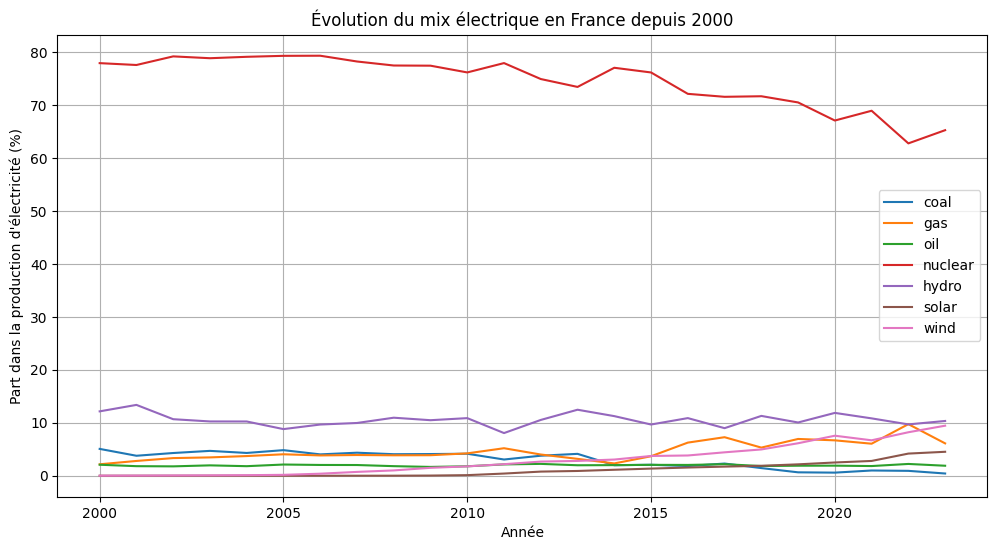

In [46]:
# Évolution du mix électrique en France depuis 2000

plt.figure(figsize=(12, 6))

for source in energy_sources:
    plt.plot(
        france_recent["year"],
        france_recent[source],
        label=source.replace("_share_elec", "")
    )

plt.title("Évolution du mix électrique en France depuis 2000")
plt.xlabel("Année")
plt.ylabel("Part dans la production d'électricité (%)")
plt.legend()
plt.grid(True)
plt.show()

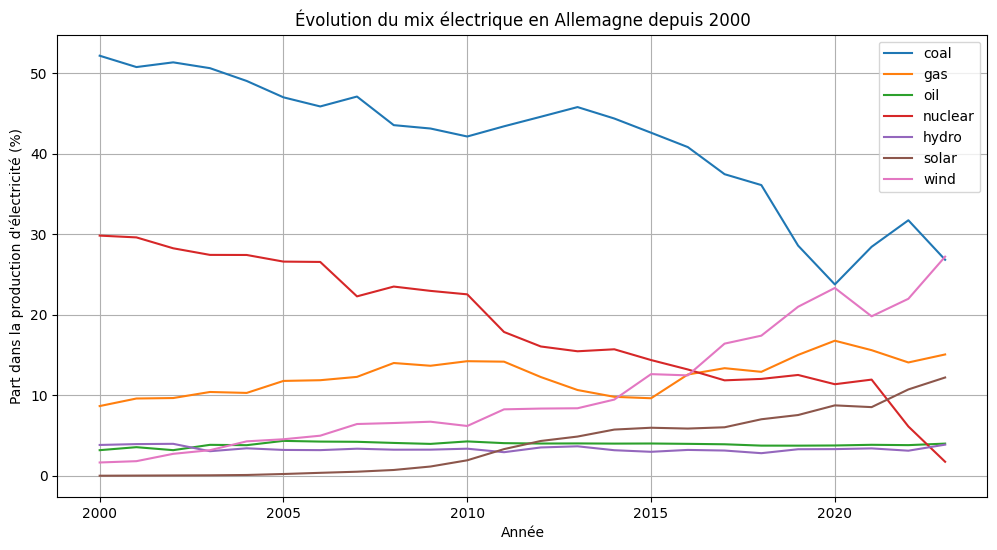

In [47]:
# Évolution du mix électrique en Allemagne depuis 2000

plt.figure(figsize=(12, 6))

for source in energy_sources:
    plt.plot(
        germany_recent["year"],
        germany_recent[source],
        label=source.replace("_share_elec", "")
    )

plt.title("Évolution du mix électrique en Allemagne depuis 2000")
plt.xlabel("Année")
plt.ylabel("Part dans la production d'électricité (%)")
plt.legend()
plt.grid(True)
plt.show()

### Interprétation

En France, la production d’électricité reste très largement dominée par le nucléaire sur toute la période, même si sa part diminue légèrement au fil du temps. L’hydraulique reste relativement stable, tandis que l’éolien et le solaire progressent surtout à partir des années 2010.

En Allemagne, le mix électrique évolue davantage. La part du charbon diminue nettement, tandis que l’éolien et le solaire augmentent fortement. La part du nucléaire baisse progressivement jusqu’à devenir presque nulle en 2023.

### Comparaison du mix électrique en 2023

Pour compléter l'analyse temporelle, on compare directement la part des principales
sources d'électricité en France et en Allemagne pour l'année 2023.

In [48]:
# Récupération des données de l'année 2023

france_2023 = france_df[france_df["year"] == 2023][energy_sources].iloc[0]
germany_2023 = germany_df[germany_df["year"] == 2023][energy_sources].iloc[0]

# Noms plus simples pour l'affichage
labels = [
    source.replace("_share_elec", "")
    for source in energy_sources
]

france_2023, germany_2023

(coal_share_elec        0.420144
 gas_share_elec         6.113478
 oil_share_elec         1.888701
 nuclear_share_elec    65.287590
 hydro_share_elec      10.346035
 solar_share_elec       4.524324
 wind_share_elec        9.455175
 Name: 123, dtype: float64,
 coal_share_elec       26.813131
 gas_share_elec        15.055765
 oil_share_elec         3.987797
 nuclear_share_elec     1.733394
 hydro_share_elec       3.859030
 solar_share_elec      12.195170
 wind_share_elec       27.197447
 Name: 123, dtype: float64)

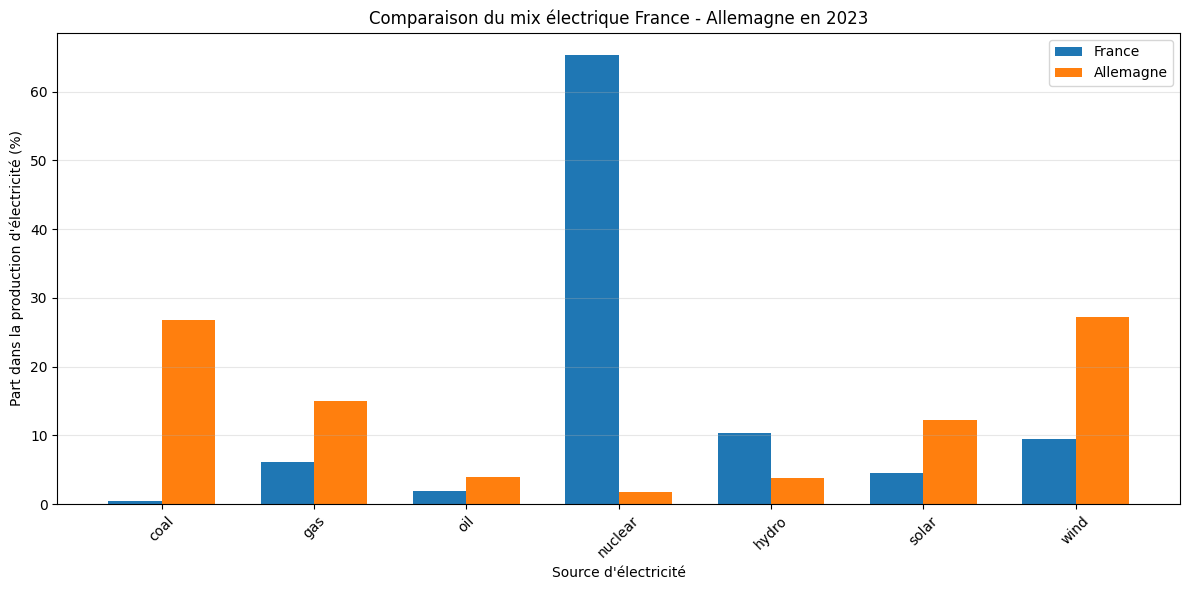

In [49]:
import numpy as np

# Position des barres sur l'axe horizontal
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    france_2023.values,
    width,
    label="France"
)

plt.bar(
    x + width/2,
    germany_2023.values,
    width,
    label="Allemagne"
)

plt.title("Comparaison du mix électrique France - Allemagne en 2023")
plt.xlabel("Source d'électricité")
plt.ylabel("Part dans la production d'électricité (%)")

plt.xticks(x, labels, rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interprétation

En 2023, le mix électrique des deux pays est très différent.

La France reste largement dominée par le nucléaire, qui représente environ les deux tiers de la production d'électricité. L'hydraulique et l'éolien occupent une place secondaire, tandis que le charbon et le pétrole sont très faibles.

En Allemagne, le mix est plus diversifié. Le charbon et l'éolien représentent une part importante de la production, suivis du gaz et du solaire. Le nucléaire est devenu très faible en 2023.

Cette comparaison montre donc deux stratégies énergétiques différentes : une forte dépendance au nucléaire en France, contre une place plus importante des énergies renouvelables et des combustibles fossiles en Allemagne.

In [50]:
# Valeurs du mix électrique en 2023 pour les deux pays

comparison_2023 = pd.DataFrame({
    "Source": labels,
    "France": france_2023.values,
    "Allemagne": germany_2023.values
})

comparison_2023.round(2)

,Source,France,Allemagne
0,coal,0.42,26.81
1,gas,6.11,15.06
2,oil,1.89,3.99
3,nuclear,65.29,1.73
4,hydro,10.35,3.86
5,solar,4.52,12.20
6,wind,9.46,27.20


### Comparaison du mix énergétique entre la France et l'Allemagne

Dans cette partie, on compare la part des principales sources d'énergie
dans la consommation énergétique totale des deux pays.

In [51]:
# Principales sources utilisées pour comparer le mix énergétique global

energy_mix_sources = [
    "coal_share_energy",
    "gas_share_energy",
    "oil_share_energy",
    "nuclear_share_energy",
    "hydro_share_energy",
    "solar_share_energy",
    "wind_share_energy"
]

In [52]:
# Données du mix énergétique pour l'année 2023

france_energy_2023 = france_df[
    france_df["year"] == 2023
][energy_mix_sources].iloc[0]

germany_energy_2023 = germany_df[
    germany_df["year"] == 2023
][energy_mix_sources].iloc[0]

In [53]:
energy_labels = [
    source.replace("_share_energy", "")
    for source in energy_mix_sources
]

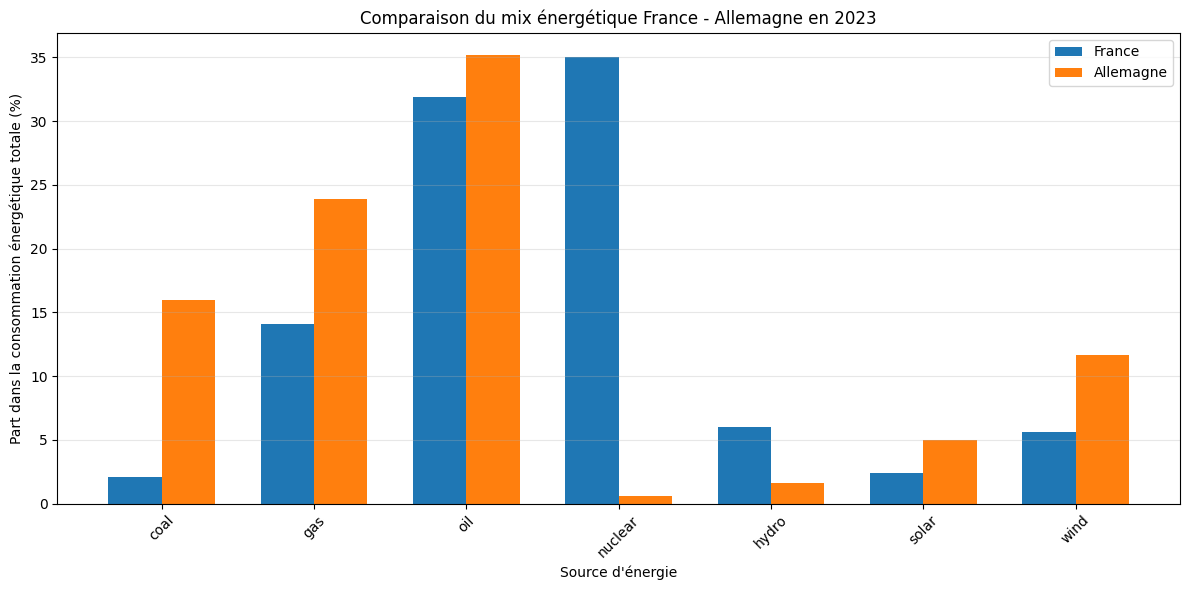

In [54]:
# Comparaison du mix énergétique France - Allemagne en 2023

x = np.arange(len(energy_labels))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    france_energy_2023.values,
    width,
    label="France"
)

plt.bar(
    x + width/2,
    germany_energy_2023.values,
    width,
    label="Allemagne"
)

plt.title("Comparaison du mix énergétique France - Allemagne en 2023")
plt.xlabel("Source d'énergie")
plt.ylabel("Part dans la consommation énergétique totale (%)")

plt.xticks(x, energy_labels, rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(IMAGES_DIR, "mix_energetique_2023.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interprétation

En 2023, le mix énergétique de la France et de l'Allemagne présente des différences importantes.

En France, le nucléaire occupe une place très importante dans la consommation énergétique totale,
avec une part d'environ 35 %. Le pétrole représente également une part élevée, autour de 32 %.

En Allemagne, le pétrole reste la principale source d'énergie, suivi du gaz et du charbon.
La part du nucléaire est en revanche très faible.

Les énergies renouvelables comme l'éolien et le solaire sont présentes dans les deux pays,
mais leur part reste plus faible que celle des principales sources fossiles ou du nucléaire.

Cette comparaison montre donc que la France repose davantage sur le nucléaire, tandis que l'Allemagne dépend davantage des combustibles fossiles comme le pétrole, le gaz et le charbon.

### Évolution de la consommation énergétique en France

Dans cette partie, on étudie l'évolution de la consommation énergétique française
selon les principales sources d'énergie.

In [55]:
# Recherche des variables liées à la consommation énergétique

[col for col in france_df.columns if "consumption" in col]

['coal_consumption',
 'fossil_fuel_consumption',
 'gas_consumption',
 'hydro_consumption',
 'low_carbon_consumption',
 'nuclear_consumption',
 'oil_consumption',
 'other_renewable_consumption',
 'primary_energy_consumption',
 'renewables_consumption',
 'solar_consumption',
 'wind_consumption',
 'biofuel_consumption']

In [56]:
# Variables de consommation pour les principales sources d'énergie

consumption_sources = [
    "coal_consumption",
    "gas_consumption",
    "oil_consumption",
    "nuclear_consumption",
    "hydro_consumption",
    "solar_consumption",
    "wind_consumption",
    "biofuel_consumption"
]

france_df[["year"] + consumption_sources].tail(10)

,year,coal_consumption,gas_consumption,oil_consumption,nuclear_consumption,hydro_consumption,solar_consumption,wind_consumption,biofuel_consumption
114,2014,107.207726,379.083527,889.425781,1134.687988,170.209198,16.020185,46.732449,32.464577
115,2015,102.279854,407.517639,902.655701,1130.385742,146.920380,19.559500,57.495407,32.747875
116,2016,99.513885,445.299377,887.998230,1035.758545,160.417267,21.857859,57.042225,32.946053
117,2017,109.046188,447.656952,901.527039,1017.314941,130.308624,24.224730,65.317886,33.203514
118,2018,100.204720,428.383850,879.651367,1048.388672,169.103683,27.324915,75.484901,32.825886
119,2019,79.423065,436.620392,872.397583,1009.287231,147.687515,30.703510,91.245125,34.181557
120,2020,55.982357,405.828369,728.388550,891.721313,162.052017,33.396385,104.869133,30.799877
121,2021,75.042389,430.413940,782.113831,952.558228,153.476151,38.937679,96.762360,34.839787
122,2022,64.418816,383.717682,777.668274,737.356934,115.418289,49.911079,98.816376,40.185539
123,2023,49.382542,338.641632,767.882080,843.038818,144.228485,57.791821,135.887115,38.802715


### Évolution de la consommation énergétique par source

On représente ici l'évolution de la consommation des principales sources d'énergie
en France afin d'identifier les sources qui diminuent ou progressent au cours du temps.

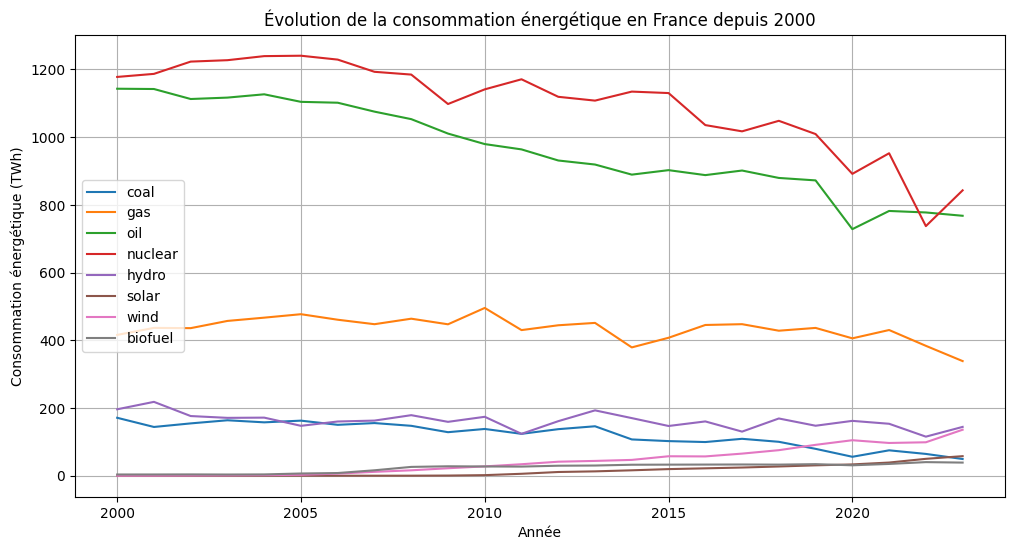

In [57]:
# On garde les données à partir de 2000 pour avoir un graphique plus lisible

france_consumption_recent = france_df[france_df["year"] >= 2000]

plt.figure(figsize=(12, 6))

for source in consumption_sources:
    plt.plot(
        france_consumption_recent["year"],
        france_consumption_recent[source],
        label=source.replace("_consumption", "")
    )

plt.title("Évolution de la consommation énergétique en France depuis 2000")
plt.xlabel("Année")
plt.ylabel("Consommation énergétique (TWh)")
plt.legend()
plt.grid(True)

plt.show()

### Interprétation

Depuis 2000, la consommation énergétique en France évolue différemment selon les sources.

Le nucléaire reste la source la plus importante sur toute la période, même si sa consommation diminue globalement, avec une baisse particulièrement visible autour de 2022 avant une remontée en 2023.

Le pétrole reste également très important, mais sa consommation diminue progressivement au fil des années.

Le gaz est plus stable, avec quelques variations, tandis que le charbon diminue fortement et devient beaucoup moins important en fin de période.

À l'inverse, les consommations liées au solaire et à l'éolien augmentent progressivement, surtout à partir des années 2010. Cela montre une progression des énergies renouvelables dans le mix énergétique français.

### Analyse des corrélations

Dans cette partie, on cherche à voir s'il existe une relation entre la consommation énergétique en France et certaines variables comme la population ou le PIB.

In [58]:
# Variable de consommation énergétique totale disponible dans le dataset

france_df["total_energy_consumption"] = france_df["primary_energy_consumption"]

In [59]:
correlation_data = france_df[
    ["year", "population", "gdp", "total_energy_consumption"]
].dropna()

In [60]:
# Vérification de la période utilisée pour le calcul des corrélations

print("Première année :", correlation_data["year"].min())
print("Dernière année :", correlation_data["year"].max())
print("Nombre d'observations :", len(correlation_data))

Première année : 1965
Dernière année : 2022
Nombre d'observations : 58


In [61]:
# Vérification des valeurs manquantes pour les variables utilisées

france_df[
    ["year", "population", "gdp", "total_energy_consumption"]
].isna().sum()

,0
year,0
population,0
gdp,1
total_energy_consumption,65


In [62]:
# Années où au moins une variable est manquante

missing_rows = france_df[
    ["year", "population", "gdp", "total_energy_consumption"]
][
    france_df[
        ["population", "gdp", "total_energy_consumption"]
    ].isna().any(axis=1)
]

missing_rows

,year,population,gdp,total_energy_consumption
0,1900,40019136,1.861012e+11,NaN
1,1901,40067484,1.830832e+11,NaN
2,1902,40116538,1.800736e+11,NaN
3,1903,40166299,1.840672e+11,NaN
4,1904,40216118,1.854181e+11,NaN
...,...,...,...,...
61,1961,46143028,5.797687e+11,NaN
62,1962,46635188,6.183765e+11,NaN
63,1963,47121244,6.504907e+11,NaN
64,1964,47641948,6.938113e+11,NaN


**Remarque :** l'analyse des corrélations est réalisée sur la période 1965–2022,
car ce sont les années pour lesquelles la population, le PIB et la consommation
énergétique totale sont disponibles simultanément.

In [63]:
# Matrice de corrélation entre consommation, population et PIB

correlation_matrix = correlation_data[
    ["population", "gdp", "total_energy_consumption"]
].corr()

correlation_matrix

,population,gdp,total_energy_consumption
population,1.000000,0.994250,0.771487
gdp,0.994250,1.000000,0.791509
total_energy_consumption,0.771487,0.791509,1.000000


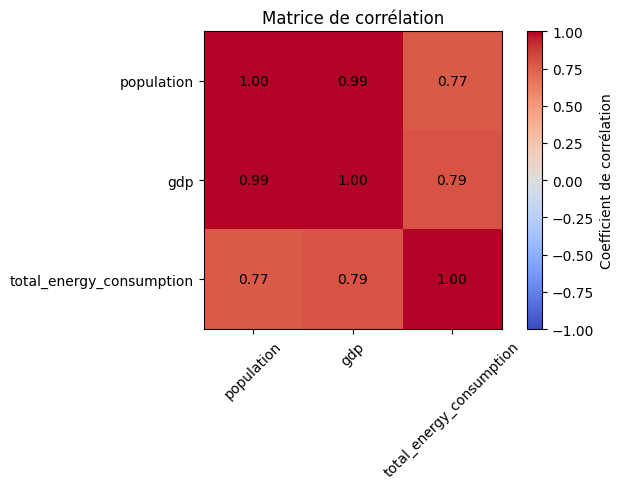

In [64]:
# Visualisation de la matrice de corrélation

plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Coefficient de corrélation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGES_DIR, "correlation_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

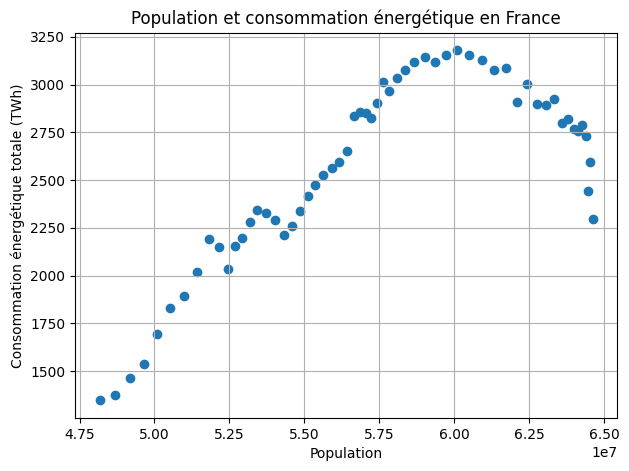

In [65]:
# Relation entre population et consommation énergétique totale

plt.figure(figsize=(7, 5))
plt.scatter(
    correlation_data["population"],
    correlation_data["total_energy_consumption"]
)

plt.title("Population et consommation énergétique en France")
plt.xlabel("Population")
plt.ylabel("Consommation énergétique totale (TWh)")
plt.grid(True)

plt.show()

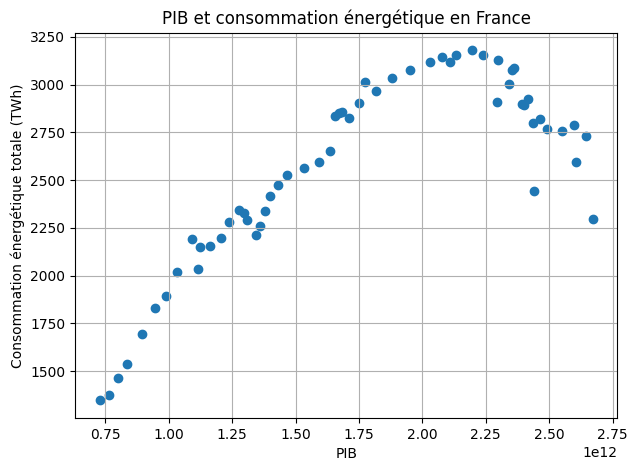

In [66]:
# Relation entre PIB et consommation énergétique totale

plt.figure(figsize=(7, 5))
plt.scatter(
    correlation_data["gdp"],
    correlation_data["total_energy_consumption"]
)

plt.title("PIB et consommation énergétique en France")
plt.xlabel("PIB")
plt.ylabel("Consommation énergétique totale (TWh)")
plt.grid(True)

plt.show()

### Interprétation des corrélations

La population et le PIB présentent une très forte corrélation positive (0,99).

La consommation énergétique totale est également positivement corrélée avec la population (0,77)
et avec le PIB (0,79). Cela montre que, sur la période 1965–2022, ces variables ont globalement
évolué dans le même sens.

Cependant, les nuages de points montrent que cette relation n'est pas parfaitement linéaire.
Pour les valeurs les plus élevées de population et de PIB, on observe même une baisse de la
consommation énergétique totale.

Ces résultats doivent donc être interprétés avec prudence. D'autres facteurs, comme
l'amélioration de l'efficacité énergétique, les changements technologiques ou l'évolution
du mix énergétique, peuvent également influencer la consommation.

Enfin, une corrélation ne permet pas d'établir une relation de causalité.

### Dashboard interactif

Dans cette partie, on crée des visualisations interactives avec Plotly et Dash
pour explorer le mix électrique de la France et de l'Allemagne et suivre l'évolution
des différentes sources d'électricité dans le temps.

In [67]:
!pip install dash plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 89.8 MB/s eta 0:00:00


In [68]:
import plotly.express as px
import plotly.graph_objects as go

from dash import Dash, dcc, html, Input, Output

In [69]:
# Préparation des données pour Plotly

mix_2023 = pd.DataFrame({
    "Source": labels,
    "France": france_2023.values,
    "Allemagne": germany_2023.values
})

mix_2023

,Source,France,Allemagne
0,coal,0.420144,26.813131
1,gas,6.113478,15.055765
2,oil,1.888701,3.987797
3,nuclear,65.287590,1.733394
4,hydro,10.346035,3.859030
5,solar,4.524324,12.195170
6,wind,9.455175,27.197447


In [70]:
# Transformation du tableau pour faciliter l'affichage avec Plotly

mix_2023_long = mix_2023.melt(
    id_vars="Source",
    var_name="Pays",
    value_name="Part"
)

mix_2023_long.head()

,Source,Pays,Part
0,coal,France,0.420144
1,gas,France,6.113478
2,oil,France,1.888701
3,nuclear,France,65.287590
4,hydro,France,10.346035


In [71]:
# Graphique interactif du mix électrique en 2023

fig = px.bar(
    mix_2023_long,
    x="Source",
    y="Part",
    color="Pays",
    barmode="group",
    title="Comparaison du mix électrique France - Allemagne en 2023",
    labels={"Part": "Part dans la production d'électricité (%)"}
)

fig.show()

### Dashboard interactif avec Dash

Ce dashboard permet de choisir un pays et une source d'énergie afin de visualiser
leur évolution dans le temps.

In [72]:
# Création de l'application Dash

app = Dash(__name__)

app.layout = html.Div([

    html.H2("Dashboard énergétique - France et Allemagne"),

    html.Label("Choisir un pays :"),

    dcc.Dropdown(
        id="country-dropdown",
        options=[
            {"label": "France", "value": "France"},
            {"label": "Allemagne", "value": "Germany"}
        ],
        value="France"
    ),

    html.Br(),

    html.Label("Choisir une source d'énergie :"),

    dcc.Dropdown(
        id="source-dropdown",
        options=[
            {"label": "Charbon", "value": "coal_share_elec"},
            {"label": "Gaz", "value": "gas_share_elec"},
            {"label": "Pétrole", "value": "oil_share_elec"},
            {"label": "Nucléaire", "value": "nuclear_share_elec"},
            {"label": "Hydraulique", "value": "hydro_share_elec"},
            {"label": "Solaire", "value": "solar_share_elec"},
            {"label": "Éolien", "value": "wind_share_elec"}
        ],
        value="nuclear_share_elec"
    ),

    dcc.Graph(id="energy-graph")
])

In [73]:
# Noms des sources pour avoir un affichage plus lisible

source_labels = {
    "coal_share_elec": "Charbon",
    "gas_share_elec": "Gaz",
    "oil_share_elec": "Pétrole",
    "nuclear_share_elec": "Nucléaire",
    "hydro_share_elec": "Hydraulique",
    "solar_share_elec": "Solaire",
    "wind_share_elec": "Éolien"
}

In [74]:
# Mise à jour du graphique selon le pays et la source choisis

@app.callback(
    Output("energy-graph", "figure"),
    Input("country-dropdown", "value"),
    Input("source-dropdown", "value")
)
def update_graph(country, source):

    if country == "France":
        df = france_recent
        country_name = "France"
    else:
        df = germany_recent
        country_name = "Allemagne"

    source_name = source_labels[source]

    fig = px.line(
        df,
        x="year",
        y=source,
        markers=True,
        title=f"Évolution de la part du {source_name.lower()} en {country_name}",
        labels={
            "year": "Année",
            source: "Part dans la production d'électricité (%)"
        }
    )

    return fig

In [75]:
app.run(debug=False)

<IPython.core.display.Javascript object>

## Conclusion générale

Ce projet a permis d'analyser les données énergétiques de plusieurs pays européens à partir du jeu de données Our World in Data.

Dans un premier temps, les données ont été explorées et filtrées afin de conserver uniquement les pays européens. Elles ont ensuite été stockées dans MongoDB Atlas avec un document par pays, ce qui a permis de structurer les données et de les interroger facilement depuis Python.

L'analyse comparative entre la France et l'Allemagne met en évidence des différences importantes aussi bien dans leur mix électrique que dans leur mix énergétique global. La France se distingue par une place très importante du nucléaire, tandis que l'Allemagne présente une part plus élevée de charbon, de gaz, de pétrole et d'énergies renouvelables comme l'éolien et le solaire.

L'étude de l'évolution de la consommation énergétique en France depuis 2000 montre également des tendances différentes selon les sources. La consommation de charbon diminue fortement, tandis que le pétrole et le nucléaire restent importants mais présentent une baisse globale sur la période. À l'inverse, les consommations liées au solaire et à l'éolien progressent progressivement.

L'analyse des corrélations, réalisée sur la période 1965–2022, montre une relation positive entre la consommation énergétique totale et la population (0,77), ainsi qu'entre la consommation énergétique totale et le PIB (0,79). Cependant, les nuages de points montrent que ces relations ne sont pas parfaitement linéaires. D'autres facteurs, comme l'amélioration de l'efficacité énergétique, les changements technologiques ou l'évolution du mix énergétique, peuvent également avoir un impact sur la consommation. Il est donc important de rappeler qu'une corrélation ne signifie pas nécessairement une relation de causalité.

Enfin, la création d'un dashboard interactif avec Plotly et Dash permet de visualiser l'évolution des différentes sources d'électricité en France et en Allemagne de manière plus dynamique.

Ce projet a donc permis de mettre en pratique plusieurs compétences en analyse de données, notamment la manipulation de fichiers JSON, l'utilisation de MongoDB, l'analyse avec Pandas, la visualisation avec Matplotlib et Plotly, ainsi que la création d'un dashboard interactif avec Dash.